In [1]:
import pandas as pd
data = pd.read_csv('E:\ML-LAB-2024-25\DataSets\Mall_customers.csv')
print(data.head())


   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


In [2]:
Features=['Annual Income (k$)','Spending Score (1-100)']
x=data[Features]
x.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


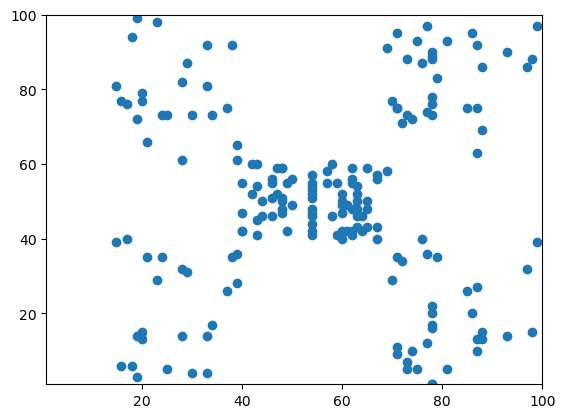

In [3]:
import matplotlib.pyplot as plt
plt.scatter(data['Annual Income (k$)'],data['Spending Score (1-100)'])
plt.xlim(1,100)
plt.ylim(1,100)
plt.show()


In [4]:
from sklearn.cluster import KMeans

import warnings
warnings.filterwarnings('ignore')

In [5]:
model = KMeans(3)
model.fit(x)

KMeans(n_clusters=3)

In [6]:
identified_clusters = model.fit_predict(x)
identified_clusters

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 2, 1, 2, 1, 2, 1, 2, 1,
       2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1,
       2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1,
       2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1,
       2, 1])

In [7]:
data_with_clusters = data.copy()
data_with_clusters['Clusters'] = identified_clusters 

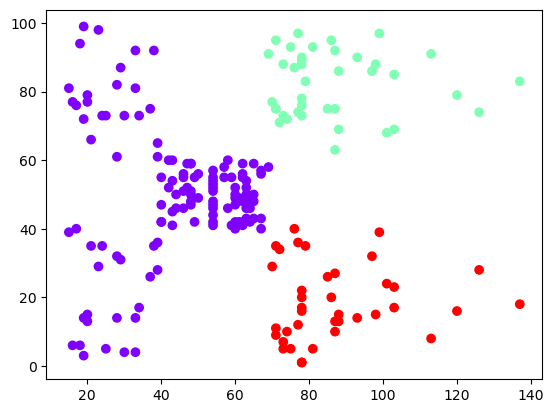

In [8]:
plt.scatter(data_with_clusters['Annual Income (k$)'],data_with_clusters['Spending Score (1-100)'],c=data_with_clusters['Clusters'],cmap='rainbow')

Text(0, 0.5, 'WCSS')

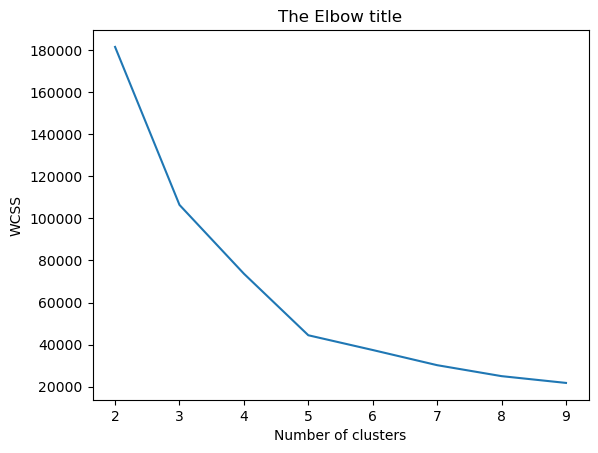

In [9]:
## Trying to find the optimal value of K (no .of clusters to be selected) using WCSS and Elbow Method
wcss=[]
for i in range(2,10):
    kmc = KMeans(i)
    kmc.fit(x)

    wcss_iter = kmc.inertia_
    wcss.append(wcss_iter)

number_clusters = range(2,10)
plt.plot(number_clusters,wcss)

plt.title('The Elbow title')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')



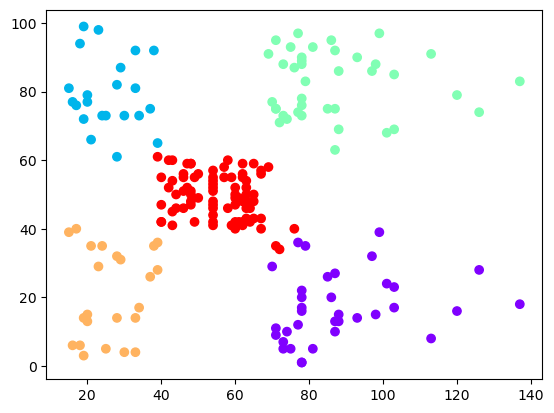

In [10]:
## from the above graph its clear that the optimal value of K is 5, so use k=5 and re-run the code
model = KMeans(5)
model.fit(x)

identified_clusters = model.fit_predict(x)
data_with_clusters['Clusters'] = identified_clusters 

plt.scatter(data_with_clusters['Annual Income (k$)'],data_with_clusters['Spending Score (1-100)'],c=data_with_clusters['Clusters'],cmap='rainbow')